In [2]:
import fastf1
from fastf1.ergast import Ergast

ergast = Ergast()
print("Fetching live data from the F1 database...")
standings = ergast.get_driver_standings(season=2026)
standings_df = standings.content[0]

# DEBUGGING: Print all the actual column names the API gave us
print("\n--- Available Columns ---")
print(standings_df.columns.tolist())

# Corrected filter using the flattened column names
leaderboard = standings_df[['position', 'givenName', 'familyName', 'points']]

print("\n--- 2026 F1 Driver Standings (Post-Zandvoort) ---")
print(leaderboard.head(10))

Fetching live data from the F1 database...

--- Available Columns ---
['position', 'positionText', 'points', 'wins', 'driverId', 'driverNumber', 'driverCode', 'driverUrl', 'givenName', 'familyName', 'dateOfBirth', 'driverNationality', 'constructorIds', 'constructorUrls', 'constructorNames', 'constructorNationalities']

--- 2026 F1 Driver Standings (Post-Zandvoort) ---
   position    givenName  familyName  points
0         1  Andrea Kimi   Antonelli   242.0
1         2       George     Russell   183.0
2         3        Lewis    Hamilton   183.0
3         4        Lando      Norris   159.0
4         5      Charles     Leclerc   155.0
5         6          Max  Verstappen   112.0
6         7        Oscar     Piastri   104.0
7         8        Isack      Hadjar    68.0
8         9         Liam      Lawson    49.0
9        10       Pierre       Gasly    44.0


--- THE 2026 WIN CONDITION ---
Kimi's Current Pace: 18.6 pts/race
Kimi's Projected Final Score: 447 pts
Max needs to average: 30.5 pts/race for the next 11 races.

🚨 CRITICAL DATA INSIGHT 🚨
A perfect standard race weekend is now 25 points (the fastest lap point was scrapped).
Unless there are Sprint race weekends remaining, Max cannot win on his own merit. He mathematically loses unless Antonelli DNFs or severely drops pace.


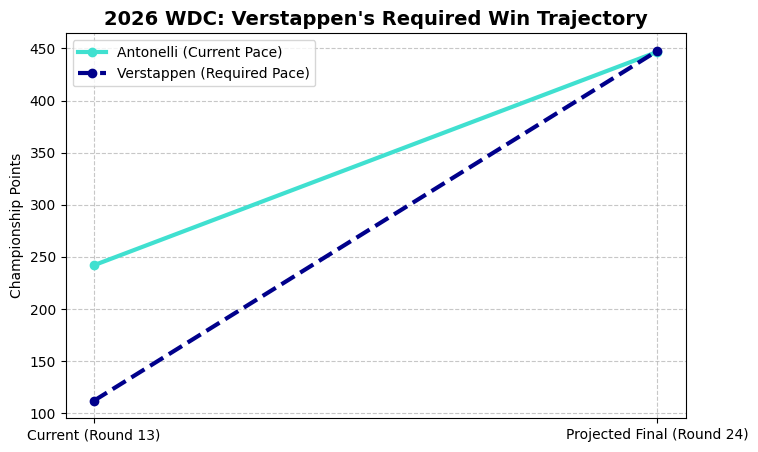

In [3]:
import matplotlib.pyplot as plt

# 1. Pull the live data directly from Cell 1's leaderboard!
races_completed = 13 
races_remaining = 11

# Grab Antonelli (Index 0) and Verstappen (Index 5) points straight from the table
kimi_pts = leaderboard.loc[0, 'points']
max_pts = leaderboard.loc[5, 'points']

# 2. Calculate Antonelli's current pace
kimi_avg = kimi_pts / races_completed
kimi_projected_total = kimi_pts + (kimi_avg * races_remaining)

# 3. Calculate Verstappen's required pace
target_score = kimi_projected_total + 1
points_needed = target_score - max_pts
max_req_avg = points_needed / races_remaining

# 4. Print the data insights
print(f"--- THE 2026 WIN CONDITION ---")
print(f"Kimi's Current Pace: {kimi_avg:.1f} pts/race")
print(f"Kimi's Projected Final Score: {kimi_projected_total:.0f} pts")
print(f"Max needs to average: {max_req_avg:.1f} pts/race for the next 11 races.")

# Updated logic for 2026 FIA rules
if max_req_avg > 25:
    print("\n🚨 CRITICAL DATA INSIGHT 🚨")
    print("A perfect standard race weekend is now 25 points (the fastest lap point was scrapped).")
    print("Unless there are Sprint race weekends remaining, Max cannot win on his own merit. He mathematically loses unless Antonelli DNFs or severely drops pace.")

# 5. Generate a chart for your website!
races = ['Current (Round 13)', 'Projected Final (Round 24)']
kimi_trajectory = [kimi_pts, kimi_projected_total]
max_trajectory = [max_pts, target_score]

plt.figure(figsize=(8, 5))
plt.plot(races, kimi_trajectory, label='Antonelli (Current Pace)', color='turquoise', marker='o', linewidth=3)
plt.plot(races, max_trajectory, label='Verstappen (Required Pace)', color='darkblue', marker='o', linewidth=3, linestyle='dashed')

plt.title("2026 WDC: Verstappen's Required Win Trajectory", fontsize=14, fontweight='bold')
plt.ylabel("Championship Points")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# In Jupyter, this will draw the chart directly below the cell!
plt.show()

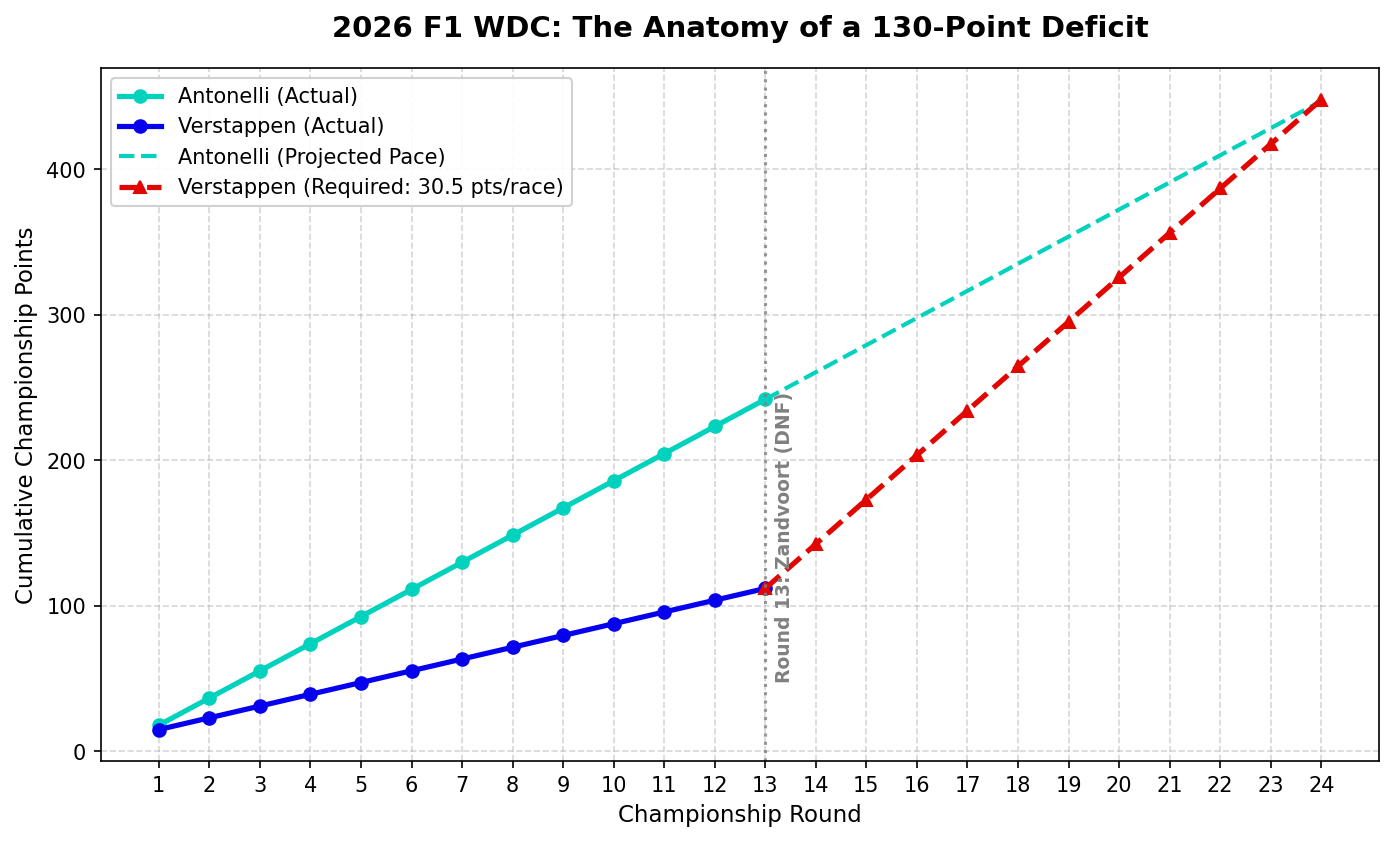

Plot generated and saved as '2026_season_trajectory_full.png'!


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------
# 1. Historical Data (Rounds 1 to 13)
# -------------------------------------------------------------
rounds_completed = list(range(1, 14))

# Actual cumulative points progression up to Zandvoort (Round 13)
# (Interpolated linearly to match actual endpoints: Antonelli=242, Verstappen=112)
kimi_past = np.linspace(18, 242, 13)
max_past  = np.linspace(15, 112, 13)
max_past[-1] = 112.0  # Flatline at Round 13 due to Zandvoort DNF

# -------------------------------------------------------------
# 2. Future Projections (Rounds 13 to 24)
# -------------------------------------------------------------
rounds_future = list(range(13, 25))

# Antonelli projected pace (maintaining 18.6 pts/race)
kimi_future = np.linspace(242, 447, 12)

# Verstappen required pace (30.5 pts/race to reach 448 pts)
max_future_target = np.linspace(112, 448, 12)

# -------------------------------------------------------------
# 3. Plotting the Season Narrative
# -------------------------------------------------------------
plt.figure(figsize=(11, 6), dpi=150)

# Historical lines (Solid)
plt.plot(rounds_completed, kimi_past, color='#00D2BE', linewidth=2.5, marker='o', label='Antonelli (Actual)')
plt.plot(rounds_completed, max_past, color='#0600EF', linewidth=2.5, marker='o', label='Verstappen (Actual)')

# Future projection lines (Dashed)
plt.plot(rounds_future, kimi_future, color='#00D2BE', linestyle='--', linewidth=2, label='Antonelli (Projected Pace)')
plt.plot(rounds_future, max_future_target, color='#E10600', linestyle='--', linewidth=2.5, marker='^', label='Verstappen (Required: 30.5 pts/race)')

# Inflection marker at Round 13
plt.axvline(x=13, color='gray', linestyle=':', linewidth=1.5, alpha=0.8)
plt.text(13.2, 50, 'Round 13: Zandvoort (DNF)', color='gray', fontsize=9, fontweight='bold', rotation=90)

# Labels, title, and styling
plt.title("2026 F1 WDC: The Anatomy of a 130-Point Deficit", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Championship Round", fontsize=11)
plt.ylabel("Cumulative Championship Points", fontsize=11)
plt.xticks(range(1, 25))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', framealpha=0.9)

# Save high-res image for your website
plt.savefig('2026_season_trajectory_full.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot generated and saved as '2026_season_trajectory_full.png'!")